In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BCI__IV_2a_PATH = "/Users/parhamkebria/Desktop/eeg_datasets/BCI_Compettition/BCI Competition IV - Data sets 2a/"

In [18]:
bci_df = pd.DataFrame()
for root, dirs, files in os.walk(BCI__IV_2a_PATH):
    for file in sorted(files):
        if not file.endswith(".csv"):
            continue
        print("Loading csv file: " + file)
        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)
        df["signal"] = df["signal"].apply(lambda value: np.asarray(ast.literal_eval(value), dtype=np.float32))
        df.trial = df.trial.str.strip().replace("array(", "").replace(", dtype=int32", "").replace(")", "")
        df.y = df.y.str.strip().replace("array(", "").replace(", dtype=uint8", "").replace(")", "")
        bci_df = pd.concat([bci_df, df], ignore_index=True)
print("All CSV files have been loaded into the DataFrame: " + str(bci_df.shape))

Loading csv file: A01T.csv
Loading csv file: A02T.csv
Loading csv file: A03T.csv
Loading csv file: A04T.csv
Loading csv file: A05T.csv
Loading csv file: A06T.csv
Loading csv file: A07T.csv
Loading csv file: A08T.csv
Loading csv file: A09T.csv
All CSV files have been loaded into the DataFrame: (79, 8)


In [19]:
bci_df

,record_index,gender,age,fs,classes,trial,y,signal
0,0,female,22,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([], dtype=uint8)]","[array([], dtype=uint8)]","[-21.142578, -23.68164, -21.484375, -25.146484..."
1,1,female,22,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([], dtype=uint8)]","[array([], dtype=uint8)]","[2.0507812, 2.8320312, -0.9277344, -4.4433594,..."
2,2,female,22,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([], dtype=uint8)]","[array([], dtype=uint8)]","[-6.9335938, -7.7148438, -5.029297, -3.8574219..."
3,3,female,22,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([4, 3, 2, 1, 1, 2, 3, 4, 2, 3, 1, 1, 1,...","[0.34179688, 0.24414062, -3.2226562, -7.861328..."
4,4,female,22,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([1, 1, 4, 2, 1, 3, 1, 3, 2, 4, 1, 3, 3,...","[-15.673828, -13.0859375, -8.886719, -13.28125..."
...,...,...,...,...,...,...,...,...
74,4,male,17,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([3, 1, 1, 4, 1, 4, 4, 2, 4, 2, 4, 3, 1,...","[11.083984, 25.488281, 21.044922, 17.480469, 1..."
75,5,male,17,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([2, 4, 1, 4, 2, 4, 1, 2, 4, 4, 2, 3, 2,...","[-2.9785156, -10.253906, -1.8554688, 5.46875, ..."
76,6,male,17,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([1, 1, 2, 4, 1, 4, 4, 4, 1, 3, 4, 4, 2,...","[6.3964844, -2.4414062, 3.0273438, 1.8066406, ..."
77,7,male,17,250,"[array(['left hand', 'right hand', 'feet', 'to...","[array([ 251, 2254, 4172, 6124, 8132, 102...","[array([4, 1, 3, 4, 2, 2, 3, 3, 1, 1, 2, 2, 1,...","[20.06836, 16.699219, 20.263672, 19.628906, 16..."


In [20]:
bci_df[["age", "gender"]].value_counts()

age  gender
24   female    16
17   male       9
22   female     9
23   female     9
     male       9
24   male       9
25   male       9
26   male       9
Name: count, dtype: int64

Length of signal[1]: 771950
Length of signal[2]: 582600
Length of signal[3]: 948400
Length of signal[4]: 2418375
Length of signal[5]: 2418375
Length of signal[6]: 2418375
Length of signal[7]: 2418375
Length of signal[8]: 2418375
Length of signal[9]: 2418375


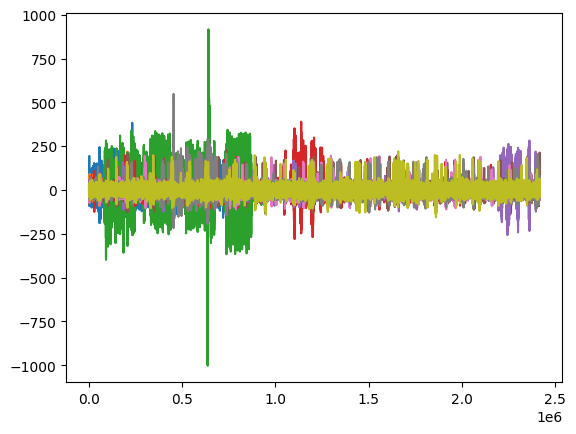

In [26]:
for i in range(len(df.signal)):
    print("Length of signal[{}]: {}".format(i+1, len(df.signal[i])))
    plt.plot(df.signal[i])
plt.show()
# plt.savefig("signal_4.png")
# plt.close("all")
